## Data Analysis Case Study: The Impact of Social Media on Mental Health
### By Idan Dana

### בחירת סט נתונים

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn import preprocessing
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
from sklearn.preprocessing import LabelEncoder
plt.style.use("ggplot")

try:
    df=pd.read_csv("Students_Social_Media_Addiction_Globally.csv")
except:
    print("Error")

### תחקור נתונים

In [5]:
print("there are", df.shape[0], "rows and", df.shape[1], "columns")

there are 6000 rows and 13 columns


In [6]:
print(df.isna().sum())
print("as you can see, there are no empty values in the file")

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64
as you can see, there are no empty values in the file


### הבנת הנתונים (EDA) 

In [9]:
print(df.describe())

        Student_ID          Age  Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night  \
count  6000.000000  6000.000000            6000.000000            6000.000000   
mean   3000.500000    20.656833               4.911500               6.863500   
std    1732.195139     1.399070               1.383228               1.258755   
min       1.000000    18.000000               0.000000               3.000000   
25%    1500.750000    19.000000               4.000000               6.000000   
50%    3000.500000    21.000000               5.000000               7.000000   
75%    4500.250000    22.000000               6.000000               8.000000   
max    6000.000000    24.000000              10.000000              11.000000   

       Mental_Health_Score  Conflicts_Over_Social_Media  Addicted_Score  
count          6000.000000                   6000.00000     6000.000000  
mean              6.245000                      2.84950        6.427667  
std               1.235407                      

In [20]:
print("the average of each numeric column: \n" ,df.mean())

SyntaxError: incomplete input (4129815727.py, line 1)

 ממוצעים אלו מספקים אינדיקציה ראשונית להתפלגות הנתונים, ומרמזים על מגמות שנבחן בהמשך כגון הקשר בין שעות שינה, רמת התמכרות ומצב נפשי

In [175]:
print("the minimum of each numeric column: \n", df.min(numeric_only=True).drop("Student_ID"))

the minimum of each numeric column: 
 Age                            18
Avg_Daily_Usage_Hours           0
Sleep_Hours_Per_Night           3
Mental_Health_Score             2
Conflicts_Over_Social_Media     0
Addicted_Score                  1
dtype: int64


מהסתכלות על ממוצע ערכי המינימום של העמודות הנומריות, ניתן לראות כי יש סטודנטים שאינם משתמשים כלל ברשתות חברתיות ומדד ההתמכרות שלהם הוא אפס, שזה דבר מעודד. מנגד, ניתן לראות כי גם קיימים סטודנטים שישנים בממוצע 3 שעות בלבד בלילה, דבר שהוא קיצוני ביחס לכל סקאלה או השוואה

In [178]:
print("the maximum of each numeric column: \n", df.max(numeric_only=True).drop("Student_ID"))

the maximum of each numeric column: 
 Age                            24
Avg_Daily_Usage_Hours          10
Sleep_Hours_Per_Night          11
Mental_Health_Score            10
Conflicts_Over_Social_Media     5
Addicted_Score                 10
dtype: int64


 אנו למדים מהסתכלות על ערכי המקסימום של העמודות הנומריות שיש סטודנטים שמשתמשים ברשתות החברתיות לא פחות מ-10 שעות ביום בממוצע. זו כמות זמן אדירה, שנרצה לבדוק את השפעתה על חיי הסטודנטים בהמשך ניתוח הנתונים

In [195]:
print("average mental health score by average daily usage hours:\n", df.groupby("Avg_Daily_Usage_Hours")["Mental_Health_Score"].mean())

average mental health score by average daily usage hours:
 Avg_Daily_Usage_Hours
0     9.000000
1     7.818182
2     7.950000
3     7.429191
4     6.790301
5     6.169221
6     5.523684
7     5.009231
8     4.859060
9     5.105263
10    5.000000
Name: Mental_Health_Score, dtype: float64


 ניתן לראת בבירור את שחשדנו. ככל שהסטודנט יגלוש פחות זמן ברשתות החברתיות, כך בריאותו הנפשית תהיה טובה יותר. אנו רואים ירידה הדרגתית בציון במדד הבריאות הנפשית ככל שמספר שעות השימוש ברשתות החברתיות בממוצע עולה. דבר מעניין מאוד הוא שהסטודנטים שכלל לא משתמשים ברשתות החברתיות, עם פער גדול מאוד מאלה שכן משתמשים ברשתות החברתיות, אפילו אם רק לשעה אחת. 

In [198]:
print(df.groupby("Avg_Daily_Usage_Hours")["Addicted_Score"].mean())

Avg_Daily_Usage_Hours
0     2.000000
1     3.272727
2     3.872222
3     4.674855
4     5.591088
5     6.557327
6     7.535965
7     8.173846
8     8.644295
9     8.894737
10    8.000000
Name: Addicted_Score, dtype: float64


 ניתן לראות מגמת עליה ברורה בציון ההתמכרות ככל שעולה זמן השימוש, למעט חריגה בקצה הגבוה (10 שעות), כנראה בשל מיעוט תצפיות.

In [201]:
print("average mental health score by sleep hours per night:\n",df.groupby("Sleep_Hours_Per_Night")["Mental_Health_Score"].mean())

average mental health score by sleep hours per night:
 Sleep_Hours_Per_Night
3     5.500000
4     5.439189
5     5.278249
6     5.502429
7     6.369978
8     6.993407
9     7.390558
10    7.633803
11    8.000000
Name: Mental_Health_Score, dtype: float64


 ניתן לראות כי ככל שהסטודנט ישן יותר שעות בלילה, ציון הבריאות הנפשי שלו עולה.

In [204]:
print("average addiction score by academic level:\n", df.groupby("Academic_Level")["Addicted_Score"].mean())

average addiction score by academic level:
 Academic_Level
Graduate         6.223389
High School      8.038462
Undergraduate    6.490013
Name: Addicted_Score, dtype: float64


 מנתונים אלה ניתן להסיק שממוצע הסטודנטים בבית ספר תיכון בעלי הניקוד הגבוה ביותר במדד ההתמכרות ביחס לנבדקים, בעוד שסטודנטים שכבר סיימו את לימודיהם בעלי ממוצע הניקוד הנמוך ביותר במדד ההתמכרות.

In [207]:
print(df.groupby("Most_Used_Platform")["Conflicts_Over_Social_Media"].mean())

Most_Used_Platform
Facebook     2.438931
Instagram    2.946429
KakaoTalk    3.000000
LINE         1.000000
LinkedIn     0.905556
Snapchat     3.230088
TikTok       3.405239
Twitter      2.431907
VKontakte    2.000000
WeChat       2.546154
WhatsApp     3.457778
YouTube      2.204545
Name: Conflicts_Over_Social_Media, dtype: float64


מנתונים אלה רואים שהכי הרבה קונפליקטים במדיה החברתית נוצרים בוואטסאפ, טיקטוק וסנאפצ'ט

In [210]:
print("average daily usage hours by gender:\n",df.groupby("Gender")["Avg_Daily_Usage_Hours"].mean())

average daily usage hours by gender:
 Gender
Female    4.992684
Male      4.829937
Name: Avg_Daily_Usage_Hours, dtype: float64


 אנו לומדים כי אין הבדל משמעותי בזמן השימוש הממוצע ברשתות החברתיות בין גברים לנשים

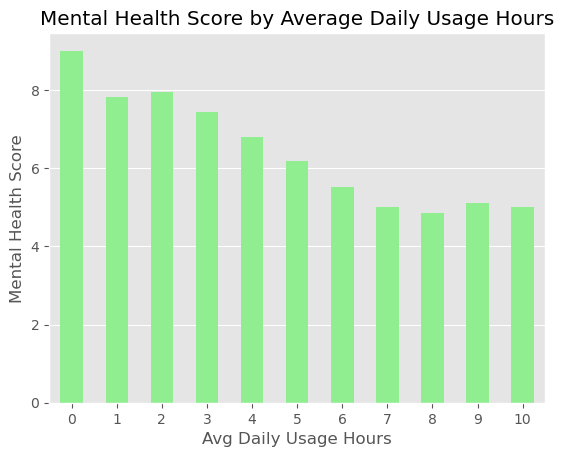

In [214]:
df.groupby("Avg_Daily_Usage_Hours")["Mental_Health_Score"].mean().plot(kind="bar", color="lightgreen")
plt.title("Mental Health Score by Average Daily Usage Hours")
plt.xlabel("Avg Daily Usage Hours")
plt.ylabel("Mental Health Score")
plt.xticks(rotation=0)
plt.grid(axis="x")
plt.show()

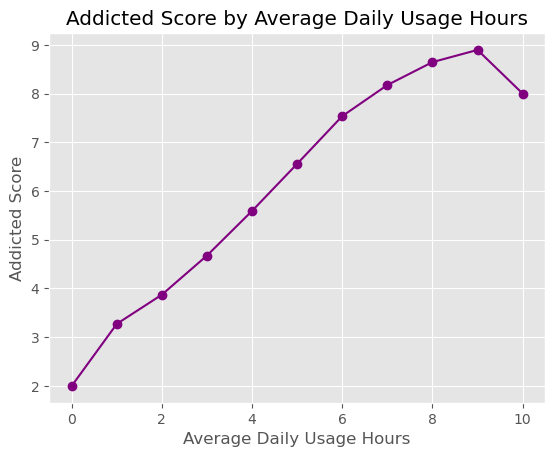

In [215]:
df.groupby("Avg_Daily_Usage_Hours")["Addicted_Score"].mean().plot(kind="line", marker='o', color="purple")
plt.title("Addicted Score by Average Daily Usage Hours")
plt.xlabel("Average Daily Usage Hours")
plt.ylabel("Addicted Score")
plt.grid(True)
plt.show()
# לא למדנו במהלך הסמסטר שימוש בגרף קווי, אך נעזרנו בבינה מלאכותית ורצינו לגוון ולהראות גרף נוסף

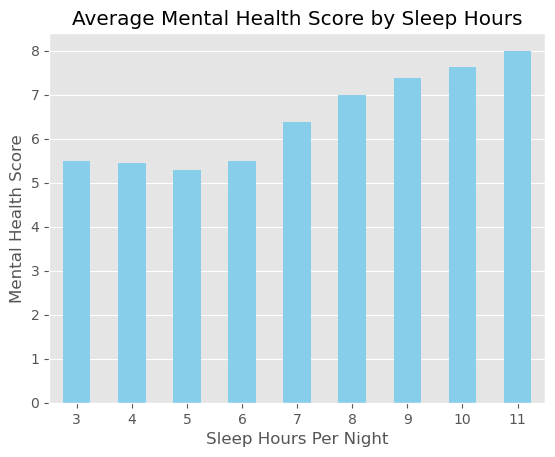

In [217]:
df.groupby("Sleep_Hours_Per_Night")["Mental_Health_Score"].mean().plot(kind="bar", color="skyblue")
plt.title("Average Mental Health Score by Sleep Hours")
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Mental Health Score")
plt.xticks(rotation=0)
plt.grid(axis="x")
plt.show()

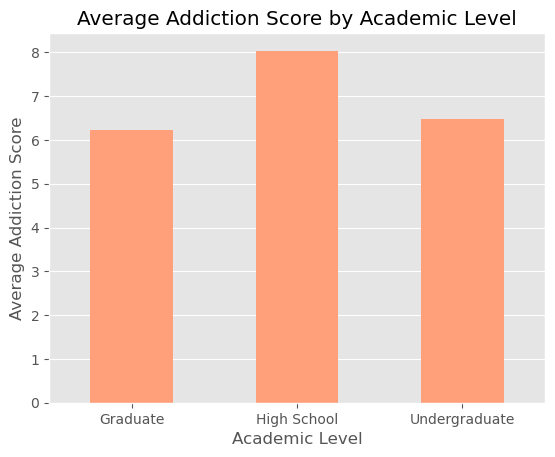

In [219]:
df.groupby("Academic_Level")["Addicted_Score"].mean().plot(kind="bar", color="lightsalmon")
plt.title("Average Addiction Score by Academic Level")
plt.xlabel("Academic Level")
plt.ylabel("Average Addiction Score")
plt.xticks(rotation=0)
plt.grid(axis="x")
plt.show()

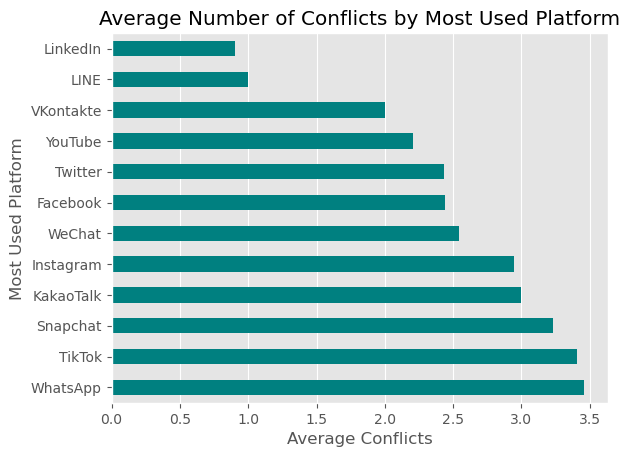

In [222]:
df.groupby("Most_Used_Platform")["Conflicts_Over_Social_Media"].mean().sort_values(ascending=False).plot(kind="barh", color="teal")
plt.title("Average Number of Conflicts by Most Used Platform")
plt.ylabel("Most Used Platform")
plt.xlabel("Average Conflicts")
plt.grid(axis="y")
plt.show()

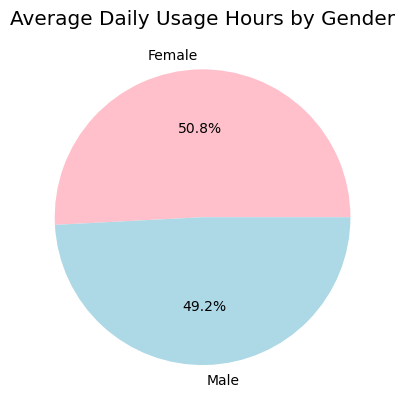

In [224]:
df.groupby("Gender")["Avg_Daily_Usage_Hours"].mean().plot(kind="pie", autopct='%1.1f%%', colors=["pink", "lightblue"])
plt.title("Average Daily Usage Hours by Gender")
plt.ylabel("")
plt.show()

###  (Data Preparation) עיבוד נתונים

לאחר שבדקנו בשלב הראשון של הפרויקט, הוכחנו כי אין לנו כלל ערכים חסרים לא בעמודות הנומריות ולא בקטגוריאליות. 
לכן בשלב עיבוד הנתונים אין צורך בפועל לבצע פעולות של השלמת ערכים חסרים או מחיקת שורות.
עם זאת, על מנת להדגים את השיטות שלמדנו בקורס, אנו מציגים כיצד ניתן היה לבצע את העיבוד במידה והיו חסרים.

In [8]:
new_df = df.dropna()
# אנו יוצרים העתק של הרשימה המקורית, רק ללא השורות של הערכים הריקים אותם השמטנו

בחרנו ליצור שלוש עמודות חדשות מתוך הנתונים הקיימים: עמודת קשיי שינה, עמודת התמכרות גבוהה ועמודת קומבינציה שמחברת בין השניים, כדי לזהות סטודנטים בעלי סיכון גבוה. זה נעשה מתוך התאמה ספציפית לשאלת המחקר שלנו על קשר בין שעות שינה, התמכרות ומצב נפשי

In [12]:
df["Sleep_Difficulty"] = df["Sleep_Hours_Per_Night"] < 7

In [14]:
df["High_Addiction"] = df["Addicted_Score"] > 7

In [16]:
df["At_Risk_Combo"] = df["Sleep_Difficulty"] & df["High_Addiction"]

#### סעיף ג

In [19]:
dummy_df= pd.get_dummies(df, dtype=int)
dummy_df.head()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Sleep_Difficulty,High_Addiction,At_Risk_Combo,...,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Affects_Academic_Performance_No,Affects_Academic_Performance_Yes,Relationship_Status_Complicated,Relationship_Status_In Relationship,Relationship_Status_Single
0,1856,22,5,3,5,4,8,True,True,True,...,0,0,0,0,0,0,1,0,1,0
1,4786,22,4,3,7,4,8,True,True,True,...,0,0,0,0,0,0,1,0,1,0
2,2822,20,9,3,6,4,8,True,True,True,...,0,0,0,0,0,0,1,0,1,0
3,699,20,9,3,5,4,9,True,True,True,...,0,0,0,0,0,0,1,0,1,0
4,2668,20,8,3,5,4,9,True,True,True,...,0,0,0,0,0,0,1,0,1,0


In [22]:
scaler = MinMaxScaler()
data = pd.DataFrame(scaler.fit_transform(dummy_df), columns=dummy_df.columns)

In [26]:
data.head(10)

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Sleep_Difficulty,High_Addiction,At_Risk_Combo,...,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Affects_Academic_Performance_No,Affects_Academic_Performance_Yes,Relationship_Status_Complicated,Relationship_Status_In Relationship,Relationship_Status_Single
0,0.309218,0.666667,0.5,0.000,0.375,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.797633,0.666667,0.4,0.000,0.625,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.470245,0.333333,0.9,0.000,0.500,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.116353,0.333333,0.9,0.000,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.444574,0.333333,0.8,0.000,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,0.564761,0.333333,0.9,0.000,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
6,0.570928,0.000000,0.6,0.000,0.500,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
7,0.059510,0.166667,0.8,0.000,0.375,0.8,1.000000,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
8,0.707618,0.333333,0.4,0.125,0.375,0.6,0.555556,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9,0.009335,0.666667,0.4,0.125,0.625,0.6,0.666667,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


### אלגוריתמי למידה

#### למידה לא מונחית

In [28]:
def get_kmeans_accuracy(data, top_k):
    sum_squared = []
    silhouette = []
    K = range(2, top_k + 1)
    for i in K:
        kmeans = KMeans(n_clusters=i, random_state=42)
        kmeans.fit(data)
        sum_squared.append(kmeans.inertia_)
        silhouette.append(silhouette_score(data, kmeans.labels_))
    return pd.DataFrame({
    "K": K,
    "SSE": sum_squared,
    "Silhouette": silhouette
    })


In [30]:
results = get_kmeans_accuracy(data, 10)
print(results)

    K           SSE  Silhouette
0   2  23301.012325    0.168160
1   3  20554.184016    0.168086
2   4  18696.691645    0.166412
3   5  17846.352440    0.160113
4   6  16535.819825    0.172963
5   7  16728.148103    0.158463
6   8  15727.054199    0.154928
7   9  15242.110988    0.162621
8  10  14452.934361    0.178114


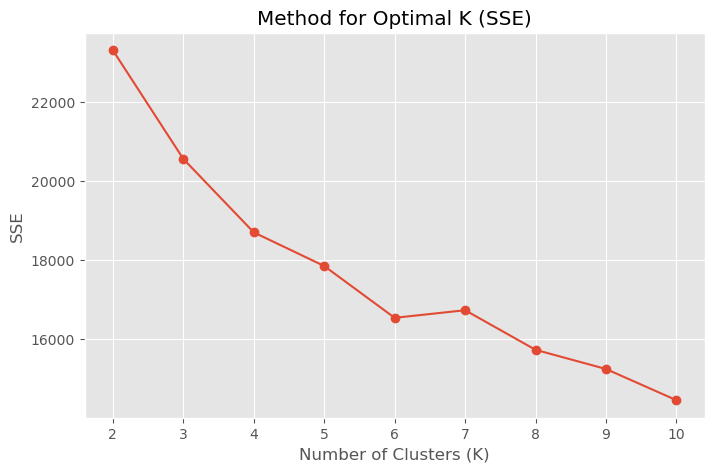

In [32]:
plt.figure(figsize=(8,5))
plt.plot(results["K"], results["SSE"], marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.title("Method for Optimal K (SSE)")
plt.grid(True)
plt.show()

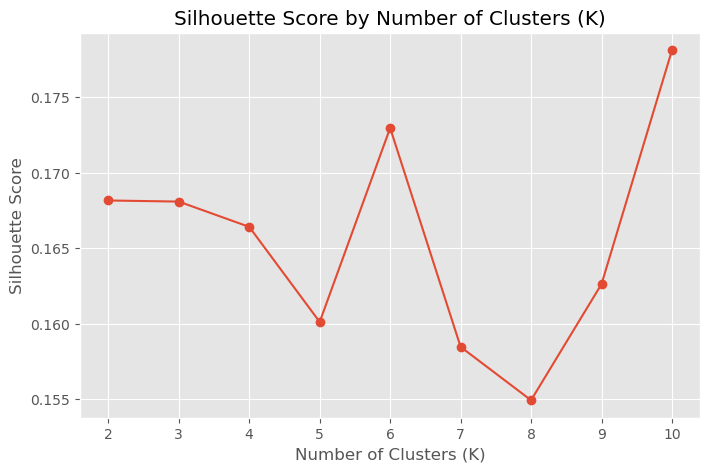

In [34]:
plt.figure(figsize=(8,5))
plt.plot(results["K"], results["Silhouette"], marker='o')
plt.title("Silhouette Score by Number of Clusters (K)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [50]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(data)

KMeans(n_clusters=3)

In [65]:
data["Cluster"] = kmeans.labels_
data.head()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Sleep_Difficulty,High_Addiction,At_Risk_Combo,...,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Affects_Academic_Performance_No,Affects_Academic_Performance_Yes,Relationship_Status_Complicated,Relationship_Status_In Relationship,Relationship_Status_Single,Cluster
0,0.309218,0.666667,0.5,0.0,0.375,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
1,0.797633,0.666667,0.4,0.0,0.625,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
2,0.470245,0.333333,0.9,0.0,0.500,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
3,0.116353,0.333333,0.9,0.0,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
4,0.444574,0.333333,0.8,0.0,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2


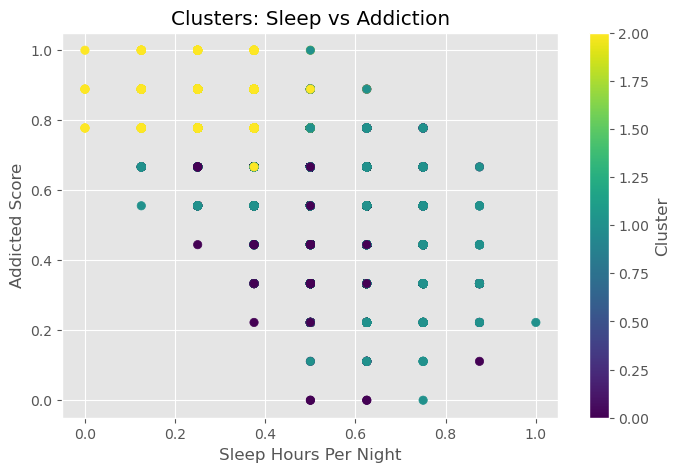

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(data["Sleep_Hours_Per_Night"],
            data["Addicted_Score"],
            c=data["Cluster"], cmap='viridis')
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Addicted Score")
plt.title("Clusters: Sleep vs Addiction")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

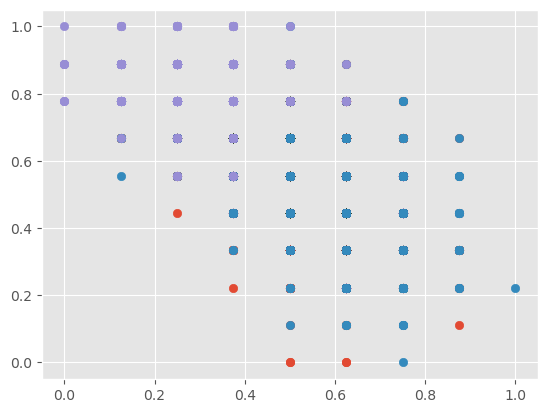

In [75]:
#אקסטרה - לא היה בעבודה המקורית 
clusters = data.groupby("Cluster")
plt.scatter(x=clusters.get_group(0)["Sleep_Hours_Per_Night"], y=clusters.get_group(0)["Addicted_Score"], label="C0")
plt.scatter(x=clusters.get_group(1)["Sleep_Hours_Per_Night"], y=clusters.get_group(1)["Addicted_Score"], label="C1")
plt.scatter(x=clusters.get_group(2)["Sleep_Hours_Per_Night"], y=clusters.get_group(2)["Addicted_Score"], label="C2")

מהגרף ניתן לראות כי קיימת חלוקה של הסטודנטים לקבוצות שונות לפי שעות השינה ורמות ההתמכרות לרשתות החברתיות.

ניתן לזהות מגמה כללית שבה סטודנטים שישנים פחות שעות נוטים להציג גם ציון התמכרות גבוה יותר, בעוד קבוצות אחרות מציגות שעות שינה רבות יותר ורמת התמכרות נמוכה.

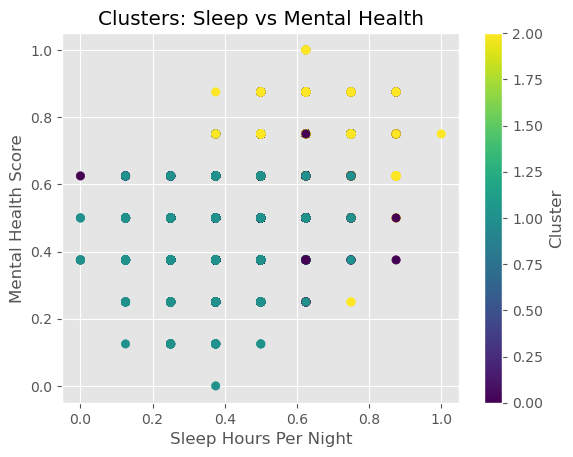

In [267]:
plt.scatter(data["Sleep_Hours_Per_Night"],
            data["Mental_Health_Score"],
            c=data["Cluster"], cmap='viridis')
plt.xlabel("Sleep Hours Per Night")
plt.ylabel("Mental Health Score")
plt.title("Clusters: Sleep vs Mental Health")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

התרשים מצביע על קשר אפשרי בין שעות השינה לבין מצב הבריאות הנפשית. 

ניתן לראות כי הקבוצה שישנה פחות שעות בממוצע נוטה גם להציג ציונים נמוכים יותר במדד הבריאות הנפשית, בעוד קבוצות עם שעות שינה גבוהות יותר שומרות על מצב נפשי טוב יותר

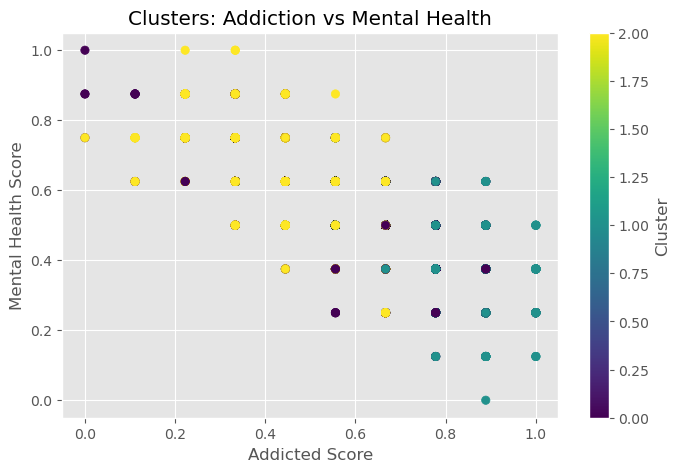

In [269]:
plt.figure(figsize=(8,5))
plt.scatter(data["Addicted_Score"],
            data["Mental_Health_Score"],
            c=data["Cluster"], cmap='viridis')
plt.xlabel("Addicted Score")
plt.ylabel("Mental Health Score")
plt.title("Clusters: Addiction vs Mental Health")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()

גרף זה מראה קשר ברור בין רמת ההתמכרות לבין מצב הבריאות הנפשית.
סטודנטים בעלי ציון התמכרות גבוה נמצאים ברובם בקבוצה עם ציוני בריאות נפשית נמוכים, דבר שתומך בהשערה על קשר שלילי בין התמכרות לרשתות החברתיות לבין רווחה נפשית.

#### למידה מונחית

In [272]:
data["Mental_Health_Label"] = data["Mental_Health_Score"].apply(lambda x: 1 if x >= 0.6 else 0)
# הפכנו את הציון הרציף לבינארי (0 או 1) כדי שהמודל ידע לחזות קטגוריות (0 או 1) ולא מספרים רציפים (בין 0 ל-1 כמו 0.7 לדוג')
data.head()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Sleep_Difficulty,High_Addiction,At_Risk_Combo,...,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Affects_Academic_Performance_No,Affects_Academic_Performance_Yes,Relationship_Status_Complicated,Relationship_Status_In Relationship,Relationship_Status_Single,Cluster,Mental_Health_Label
0,0.309218,0.666667,0.5,0.0,0.375,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,0
1,0.797633,0.666667,0.4,0.0,0.625,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0,1
2,0.470245,0.333333,0.9,0.0,0.500,0.8,0.777778,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0
3,0.116353,0.333333,0.9,0.0,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0
4,0.444574,0.333333,0.8,0.0,0.375,0.8,0.888889,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1,0


In [320]:
X = data[["Sleep_Hours_Per_Night", "Avg_Daily_Usage_Hours", "Addicted_Score", "Conflicts_Over_Social_Media"]]
y = data["Mental_Health_Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

In [274]:
Rf = RandomForestClassifier(n_estimators=200)
Rf.fit(X_train, y_train)
Rf_pred = Rf.predict(X_test)

In [275]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, Rf_pred))

Confusion Matrix:
 [[812  69]
 [110 509]]


In [277]:
print("Accuracy Score:", metrics.accuracy_score(y_test, Rf_pred))

Accuracy Score: 0.8806666666666667


In [278]:
print(data["Mental_Health_Label"].value_counts())

Mental_Health_Label
0    3492
1    2508
Name: count, dtype: int64


In [279]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": Rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances)

                       Feature  Importance
3  Conflicts_Over_Social_Media    0.460173
2               Addicted_Score    0.346075
1        Avg_Daily_Usage_Hours    0.127370
0        Sleep_Hours_Per_Night    0.066381


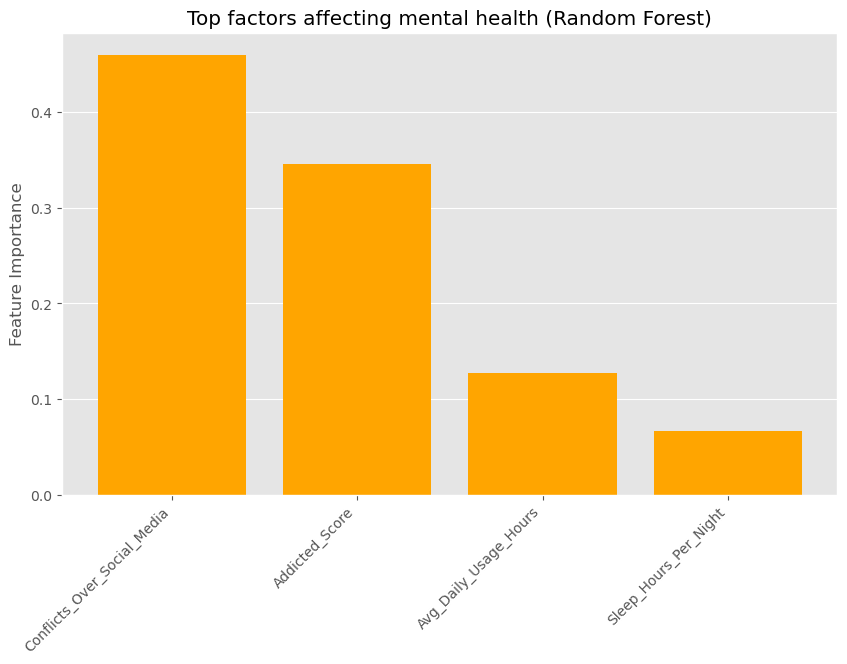

In [318]:
plt.figure(figsize=(10,6))
plt.bar(importances["Feature"], importances["Importance"], color='orange')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Feature Importance")
plt.title("Top factors affecting mental health (Random Forest)")
plt.grid(axis="x")
plt.show()

הפעלנו את אלגוריתם רנדום פורסט על הפיצ’רים שנבחרו במיוחד לשאלת המחקר שלנו- שעות שינה, זמן שימוש ברשתות, רמת קונפליקטים במדיה ורמת התמכרות, על מנת לבדוק אילו מהם משפיעים הכי הרבה על התחזית למצב נפשי ירוד.

##### מסקנות ותובנות מתוצאות המודל
1. רמת הקונפליקטים ברשתות החברתיות היא הפיצ'ר שהמודל סימן כהכי משפיע על המצב הנפשי. אמנם זו תוצאה מעניינת שלא הייתה במוקד שאלת המחקר שלנו, אך היא מדגישה שהאינטראקציות השליליות ברשתות עלולות להכביד מאוד על הבריאות הנפשית.
2. רמת ההתמכרות לרשתות החברתיות, שהייתה אחד המרכזיים בשאלת המחקר שלנו, קיבלה את המשקל השני בחשיבותה - מה שמחזק את ההשערה שלנו שהשימוש הכפייתי במדיה עלול לפגוע במצב הנפשי.
3. מספר שעות השינה בלילה, אף על פי שמשפיע פחות מהגורמים שמעליו, עדיין קיבל חשיבות מסוימת במודל — מה שתומך בקשר שקיים בין חסך שינה לבין מצוקה נפשית.

לסיכום, ניתוח הפיצ'רים באמצעות רנדום פורסט אפשר לנו לזהות מהם הגורמים המרכזיים המשפיעים על התחזית של המודל שלנו למצב נפשי ירוד, ולבחון את ההתאמה של הממצאים להשערת המחקר המקורית.